---
title: "CRE y FRT"
description: "Experimentos Completamente Aleatorizados y Prueba de Aleatorización de Fisher"
categories: [Causal Inference]
order: 2
---

In [1]:
from scipy.special import comb
import os
import pandas as pd
from statsmodels.stats.weightstats import ttest_ind
import numpy as np
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

import os
if 'COLAB_GPU' in os.environ:
  from google.colab import drive
  drive.mount("/content/drive/")

  path = "/content/drive/MyDrive/Estudios/ding/data"
  df = pd.read_csv(os.path.join(path, "lalonde.csv"))

else:
  df = pd.read_csv("data/lalonde.csv")

# Experimentos Completamente Aleatorizados y Prueba de Aleatorización de Fisher

## Experimento Completamente Aleatorizado

<br>

**Definición: CRE (Experimento Completamente Aleatorizado)**
Consideremos un experimento con $n$ unidades, de las cuales a $n_1$ unidades se les aplicará el tratamiento y a $n_0$ se les aplicará el control, $n=n_1+n_0$. Un Experimento completamente aleatorizado (CRE) es uno en el cuál el mecanismo de asignación de tratamiento (la distribución de probabilidad) es la siguiente:

$$pr(Z=z) = \frac{1}{\binom{n}{n_1}}$$
<br>
*En palabras*:

La probabilidad del vector de asignaciones es igual al inverso de las combinaciones tomando $n_1$ unidades de asignación. Todos los vectores de asignación son equiprobables (distribución uniforme).

<br>

*Implicaciones*

 - $Z \perp\!\!\!\perp \{ Y(1), Y(0)\}$

In [2]:
# Ejemplo de una distribución de asignación
# Considera un experimento en el que tienes 10 unidades y 3 tendrán tratamiento
n = 10
n1 = 3
comb_ = comb(n,n1)
comb_
p_z = float(1 / comb_)
p_z

0.008333333333333333

## Fisher Randomization Test (FRT)


Una hipótesis nula de interés es la siguiente:

$$H_{0F}: Y_i(0) = Y_i(1)\text{ para todas las unidades } i = 1,...,n$$

Hay que notar que bajo esta hipótesis nula, entonces conoces todos los resultados potenciales cuando obtienes los resultados observados.

De esta forma, el valor del estadístico para cualquier vector de asignación  posible sin necesidad de realizar supuestos sobre la distribución.

$$T=T(Z,Y)$$

Bajo la hipótesis nula, el valor del vector de resultados observados $Y$ es fijo, así que el único elemento aleatorio es el vector de asignación $Z$. Como el experimentador es quien determina la distribución de $Z$, entonces el experimentador determina la distribución de $T$ bajo $H_{0F}$.

<br>

En un CRE, la distribución de $Z$ es uniforme por lo que también $T$ se distribuye uniforme. Esta distribución se denota como *distribución de aleatorización*.

$$\{T(z^1,Y), ..., T(z^M,Y)\}$$

Donde $M = \binom{n}{n_1}$, es decir, el número de permutaciones posibles.


<br>

Podemos calcular el p-value, es decir, la probabilidad de observar un valor del estadístico tan extremo o más que el observado, bajo la distribución de aleatorización:

$$p_{FRT}=M^{-1}\sum_{m=1}^{M}I\{T(z^m,Y)>=T(Z,Y)\}$$

## Elecciones canónicas del estadístico de prueba

### Diferencia de medias

In [3]:
z = df["treat"].values
y = df["re78"].values

# Diferencia de medias
tauhat = ttest_ind(y[z==1], y[z==0],  usevar='pooled')[0]

# Prueba t
t = ttest_ind(y[z==1], y[z==0],  usevar='unequal')[0]

# Wilcoxon rank- test
w = mannwhitneyu(y[z==1], y[z==0])[0]

# Kolmogorov-Smirnoff test
d = np.round(ks_2samp(y[z==1], y[z==0])[0], 7)

# Aproximación Monte Carlo de la distribución de aleatorización
MC = int(10**4)
Tauhat = np.zeros(MC)
Student = np.zeros(MC)
Wilcox = np.zeros(MC)
Ks =  np.zeros(MC)

for i in range(MC):
  zperm = np.random.permutation(z)
  Tauhat[i]= ttest_ind(y[zperm==1], y[zperm==0],  usevar='pooled')[0]
  Student[i]= ttest_ind(y[zperm==1], y[zperm==0],  usevar='unequal')[0]
  Wilcox[i] = mannwhitneyu(y[zperm==1], y[zperm==0])[0]
  Ks[i] = ks_2samp(y[zperm==1], y[zperm==0])[0]

# p-values exactos
print("Estadístico de diferencia de medias:", np.round(tauhat, 6))
print("Valor-p exacto de la prueba de diferencia de medias:", np.mean(Tauhat >= tauhat))
print("-"*50)

print("Estadístico de t-student:", np.round(t, 6))
print("Valor-p exacto de la prueba t-Student:", np.mean(Student >= t))
print("-"*50)

print("Estadístico de Wilcoxon:", np.round(w, 6))
print("Valor-p exacto de la prueba de Wilcoxon:", np.mean(Wilcox >= w))
print("-"*50)

print("Estadístico de Kolmogorov-Smirnoff:", np.round(d, 6))
print("Valor-p exacto de la prueba de Kolmogorov-Smirnoff:", np.mean(Ks >= d))


Estadístico de diferencia de medias: 2.835321
Valor-p exacto de la prueba de diferencia de medias: 0.0025
--------------------------------------------------
Estadístico de t-student: 2.674146
Valor-p exacto de la prueba t-Student: 0.0026
--------------------------------------------------
Estadístico de Wilcoxon: 27402.5
Valor-p exacto de la prueba de Wilcoxon: 0.0045
--------------------------------------------------
Estadístico de Kolmogorov-Smirnoff: 0.132121
Valor-p exacto de la prueba de Kolmogorov-Smirnoff: 0.0384


Text(0.5, 1.0, 'Kolmogorov-Smirnoff')

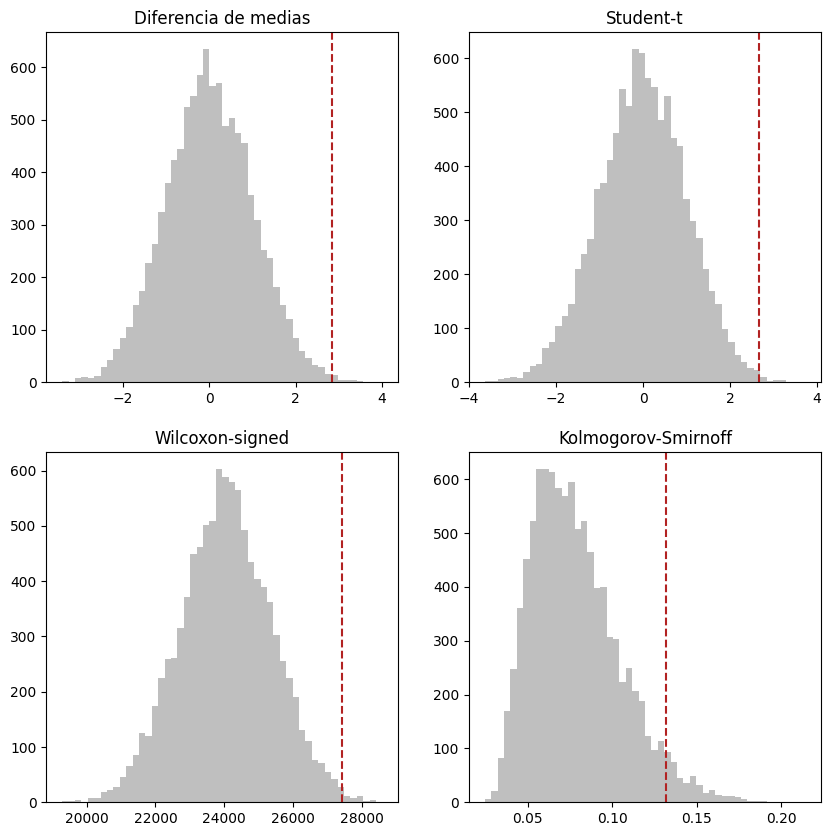

In [4]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10,10))
ax[0,0].hist(Tauhat, bins=50, color='grey', alpha = 0.5)
ax[0,0].axvline(x = tauhat, color = 'firebrick', linestyle='--')
ax[0,0].set_title('Diferencia de medias')

ax[0,1].hist(Student, bins=50, color='grey', alpha = 0.5)
ax[0,1].axvline(x = t, color = 'firebrick', linestyle='--')
ax[0,1].set_title('Student-t')

ax[1,0].hist(Wilcox, bins=50, color='grey', alpha = 0.5)
ax[1,0].axvline(x = w, color = 'firebrick', linestyle='--')
ax[1,0].set_title('Wilcoxon-signed')

ax[1,1].hist(Ks, bins=50, color='grey', alpha = 0.5)
ax[1,1].axvline(x = d, color = 'firebrick', linestyle='--')
ax[1,1].set_title('Kolmogorov-Smirnoff')

